# Inits

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import numpy as np
import pandas as pd

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Dictionary to store results for Task 6
model_results = {}

In [4]:
# Helper function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#Task 1 - Data Exploration and Preprocessing

In [5]:
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalizes to range [-1, 1]
])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [6]:
# Split 5:1
train_dataset, val_dataset = random_split(full_train_dataset, [50000, 10000])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [7]:
def show_random_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(12, 3))
    indices = np.random.choice(len(dataset), num_images, replace=False)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # Un-normalize for displaying: img * 0.5 + 0.5
        img_display = img.squeeze() * 0.5 + 0.5
        axes[i].imshow(img_display, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

Displaying 5 random images from the dataset:


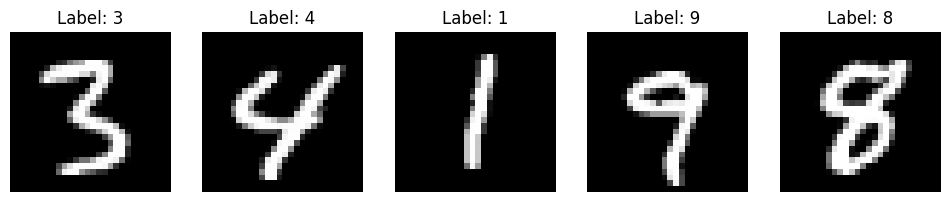

In [8]:
print("Displaying 5 random images from the dataset:")
show_random_images(train_dataset)

In [9]:
#Range print
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")

Batch shape: torch.Size([64, 1, 28, 28])


# Helper Training Function

In [10]:
def train_and_evaluate(model, model_name, epochs=10):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    training_time = time.time() - start_time

    # Test Evaluation
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    test_acc = 100 * test_correct / test_total


    model_results[model_name] = {
        'params': count_parameters(model),
        'time': training_time,
        'accuracy': test_acc
    }


    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss Curve')
    plt.legend()
    plt.show()

    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")
    return model, train_losses, val_losses, test_acc

#Task 2 - Architecture Design Experiment


In [11]:
Model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

In [12]:
Model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [13]:
Model_C = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

Training Model A (784 -> 32 -> 10)
Epoch [1/10] - Train Loss: 0.5006, Val Loss: 0.3193, Val Acc: 90.97%
Epoch [2/10] - Train Loss: 0.3045, Val Loss: 0.2901, Val Acc: 91.66%
Epoch [3/10] - Train Loss: 0.2702, Val Loss: 0.2718, Val Acc: 92.52%
Epoch [4/10] - Train Loss: 0.2421, Val Loss: 0.2352, Val Acc: 93.34%
Epoch [5/10] - Train Loss: 0.2208, Val Loss: 0.2327, Val Acc: 93.41%
Epoch [6/10] - Train Loss: 0.2055, Val Loss: 0.2133, Val Acc: 93.92%
Epoch [7/10] - Train Loss: 0.1869, Val Loss: 0.1916, Val Acc: 94.73%
Epoch [8/10] - Train Loss: 0.1749, Val Loss: 0.2065, Val Acc: 94.06%
Epoch [9/10] - Train Loss: 0.1645, Val Loss: 0.1826, Val Acc: 94.95%
Epoch [10/10] - Train Loss: 0.1558, Val Loss: 0.1763, Val Acc: 95.11%


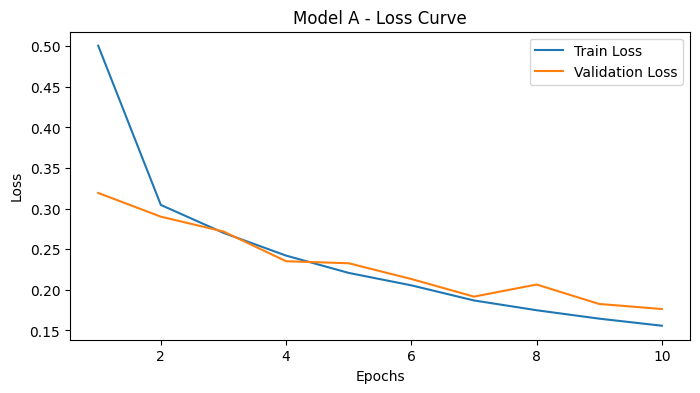

Model A - Test Accuracy: 95.45%



In [14]:
print("Training Model A (784 -> 32 -> 10)")
Model_A, _, _, _ = train_and_evaluate(Model_A, "Model A", epochs=10)

Training Model B (784 -> 128 -> 64 -> 10)
Epoch [1/10] - Train Loss: 0.4364, Val Loss: 0.2671, Val Acc: 91.99%
Epoch [2/10] - Train Loss: 0.2148, Val Loss: 0.1999, Val Acc: 93.92%
Epoch [3/10] - Train Loss: 0.1519, Val Loss: 0.1557, Val Acc: 95.35%
Epoch [4/10] - Train Loss: 0.1245, Val Loss: 0.1509, Val Acc: 95.42%
Epoch [5/10] - Train Loss: 0.1038, Val Loss: 0.1497, Val Acc: 95.57%
Epoch [6/10] - Train Loss: 0.0906, Val Loss: 0.1380, Val Acc: 95.93%
Epoch [7/10] - Train Loss: 0.0800, Val Loss: 0.1088, Val Acc: 96.86%
Epoch [8/10] - Train Loss: 0.0707, Val Loss: 0.1051, Val Acc: 97.05%
Epoch [9/10] - Train Loss: 0.0663, Val Loss: 0.1061, Val Acc: 97.23%
Epoch [10/10] - Train Loss: 0.0591, Val Loss: 0.1166, Val Acc: 96.70%


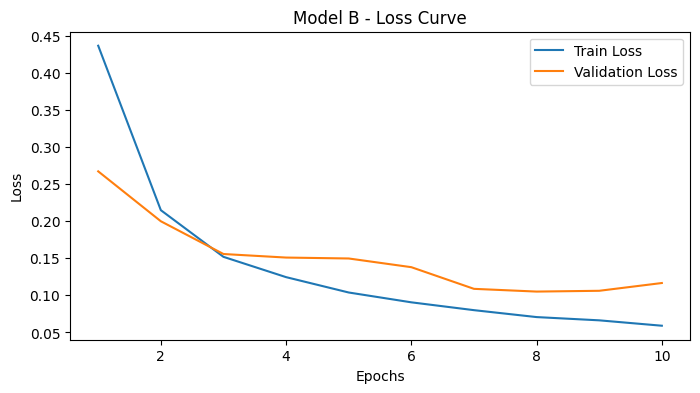

Model B - Test Accuracy: 96.82%



In [15]:
print("Training Model B (784 -> 128 -> 64 -> 10)")
Model_B, _, _, _ = train_and_evaluate(Model_B, "Model B", epochs=10)

Training Model C (784 -> 256 -> 128 -> 64 -> 10)
Epoch [1/10] - Train Loss: 0.3921, Val Loss: 0.2144, Val Acc: 93.45%
Epoch [2/10] - Train Loss: 0.1747, Val Loss: 0.1496, Val Acc: 95.46%
Epoch [3/10] - Train Loss: 0.1310, Val Loss: 0.1318, Val Acc: 96.01%
Epoch [4/10] - Train Loss: 0.1060, Val Loss: 0.1325, Val Acc: 96.04%
Epoch [5/10] - Train Loss: 0.0900, Val Loss: 0.1290, Val Acc: 96.20%
Epoch [6/10] - Train Loss: 0.0783, Val Loss: 0.1478, Val Acc: 95.74%
Epoch [7/10] - Train Loss: 0.0675, Val Loss: 0.1253, Val Acc: 96.29%
Epoch [8/10] - Train Loss: 0.0609, Val Loss: 0.1036, Val Acc: 97.07%
Epoch [9/10] - Train Loss: 0.0531, Val Loss: 0.0917, Val Acc: 97.48%
Epoch [10/10] - Train Loss: 0.0499, Val Loss: 0.0905, Val Acc: 97.50%


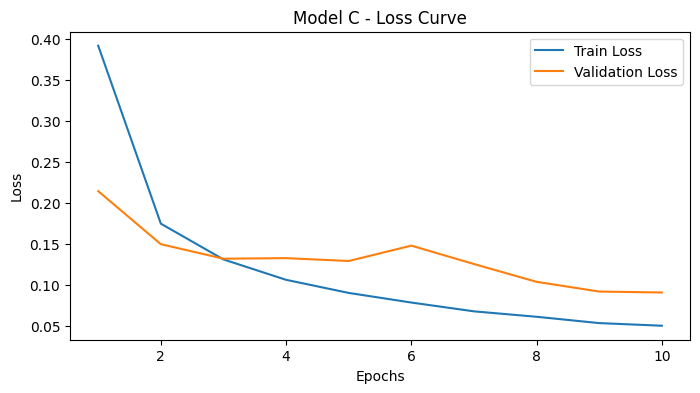

Model C - Test Accuracy: 97.77%



In [16]:
print("Training Model C (784 -> 256 -> 128 -> 64 -> 10)")
Model_C, _, _, _ = train_and_evaluate(Model_C, "Model C", epochs=10)

# Task 3 - Underfitting vs Overfitting

In [17]:
Model_Underfit = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 4),
    nn.ReLU(),
    nn.Linear(4, 10)
)

In [18]:
Model_Overfit = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 1024), nn.ReLU(),
    nn.Linear(1024, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)

Training Model 1 (Very Small - Expected to Underfit)
Epoch [1/10] - Train Loss: 1.9988, Val Loss: 1.8670, Val Acc: 22.24%
Epoch [2/10] - Train Loss: 1.8339, Val Loss: 1.7967, Val Acc: 24.74%
Epoch [3/10] - Train Loss: 1.7869, Val Loss: 1.7685, Val Acc: 24.75%
Epoch [4/10] - Train Loss: 1.7625, Val Loss: 1.7453, Val Acc: 27.19%
Epoch [5/10] - Train Loss: 1.7486, Val Loss: 1.7352, Val Acc: 28.62%
Epoch [6/10] - Train Loss: 1.7354, Val Loss: 1.7231, Val Acc: 29.22%
Epoch [7/10] - Train Loss: 1.7267, Val Loss: 1.7176, Val Acc: 31.80%
Epoch [8/10] - Train Loss: 1.7194, Val Loss: 1.7065, Val Acc: 31.12%
Epoch [9/10] - Train Loss: 1.7132, Val Loss: 1.7030, Val Acc: 33.00%
Epoch [10/10] - Train Loss: 1.7069, Val Loss: 1.7045, Val Acc: 32.33%


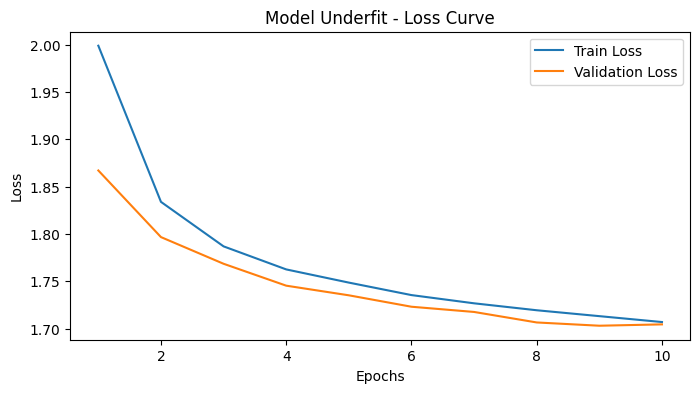

Model Underfit - Test Accuracy: 31.53%



(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Linear(in_features=784, out_features=4, bias=True)
   (2): ReLU()
   (3): Linear(in_features=4, out_features=10, bias=True)
 ),
 [1.9988252646255493,
  1.83387989402771,
  1.7868613796234132,
  1.7625260059356689,
  1.7485906449127198,
  1.7354000540924073,
  1.7267107349395752,
  1.7193812606811523,
  1.7131564471435548,
  1.7069307663726807],
 [1.8670413806915283,
  1.79666754322052,
  1.7684803173065184,
  1.7453491458892822,
  1.7351627742767335,
  1.7230987854003905,
  1.7175869913101196,
  1.7064891628265382,
  1.7030403966903687,
  1.7044597347259522],
 31.53)

In [19]:
print("Training Model 1 (Very Small - Expected to Underfit)")
train_and_evaluate(Model_Underfit, "Model Underfit", epochs=10)

Training Model 2 (Very Large - Expected to Overfit)
Epoch [1/10] - Train Loss: 0.4874, Val Loss: 0.2348, Val Acc: 92.97%
Epoch [2/10] - Train Loss: 0.1898, Val Loss: 0.1932, Val Acc: 94.23%
Epoch [3/10] - Train Loss: 0.1466, Val Loss: 0.1546, Val Acc: 95.55%
Epoch [4/10] - Train Loss: 0.1193, Val Loss: 0.1329, Val Acc: 96.26%
Epoch [5/10] - Train Loss: 0.1038, Val Loss: 0.1156, Val Acc: 96.87%
Epoch [6/10] - Train Loss: 0.0937, Val Loss: 0.1371, Val Acc: 96.38%
Epoch [7/10] - Train Loss: 0.0797, Val Loss: 0.1227, Val Acc: 97.12%
Epoch [8/10] - Train Loss: 0.0713, Val Loss: 0.1333, Val Acc: 96.91%
Epoch [9/10] - Train Loss: 0.0643, Val Loss: 0.1048, Val Acc: 97.28%
Epoch [10/10] - Train Loss: 0.0617, Val Loss: 0.1092, Val Acc: 97.48%


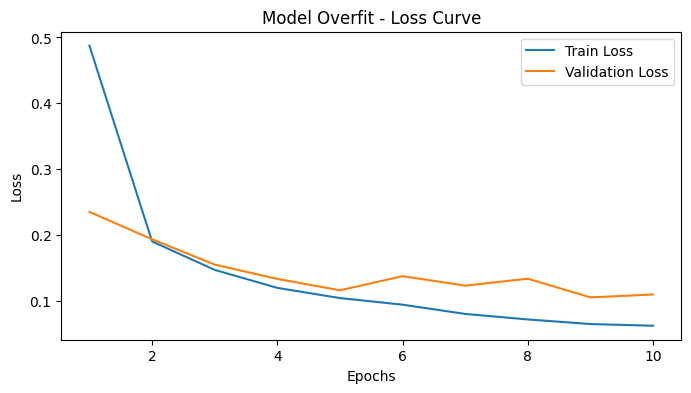

Model Overfit - Test Accuracy: 97.36%



(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Linear(in_features=784, out_features=1024, bias=True)
   (2): ReLU()
   (3): Linear(in_features=1024, out_features=512, bias=True)
   (4): ReLU()
   (5): Linear(in_features=512, out_features=512, bias=True)
   (6): ReLU()
   (7): Linear(in_features=512, out_features=256, bias=True)
   (8): ReLU()
   (9): Linear(in_features=256, out_features=128, bias=True)
   (10): ReLU()
   (11): Linear(in_features=128, out_features=64, bias=True)
   (12): ReLU()
   (13): Linear(in_features=64, out_features=10, bias=True)
 ),
 [0.4873986275625229,
  0.1898320858424902,
  0.14661282851815224,
  0.11928139186859131,
  0.10376467644631862,
  0.0937339534085989,
  0.07967125740021468,
  0.07128557902023196,
  0.06430473888136447,
  0.06174960775509477],
 [0.23475459628105164,
  0.19316656016111375,
  0.15464863518476485,
  0.13293230203390122,
  0.11560966928601266,
  0.13707076098918916,
  0.12268250837773084,
  0.1332517080873251,
  0.1048301

In [20]:
print("Training Model 2 (Very Large - Expected to Overfit)")
train_and_evaluate(Model_Overfit, "Model Overfit", epochs=10)

# Task 4 - Batch Normalization Study

In [21]:
Model_B_BatchNorm = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

Training Model B with Batch Normalization
Epoch [1/10] - Train Loss: 0.2796, Val Loss: 0.1254, Val Acc: 96.10%
Epoch [2/10] - Train Loss: 0.1019, Val Loss: 0.0951, Val Acc: 97.18%
Epoch [3/10] - Train Loss: 0.0723, Val Loss: 0.0921, Val Acc: 97.06%
Epoch [4/10] - Train Loss: 0.0541, Val Loss: 0.0810, Val Acc: 97.55%
Epoch [5/10] - Train Loss: 0.0458, Val Loss: 0.0864, Val Acc: 97.44%
Epoch [6/10] - Train Loss: 0.0375, Val Loss: 0.0841, Val Acc: 97.61%
Epoch [7/10] - Train Loss: 0.0339, Val Loss: 0.0807, Val Acc: 97.62%
Epoch [8/10] - Train Loss: 0.0272, Val Loss: 0.0817, Val Acc: 97.71%
Epoch [9/10] - Train Loss: 0.0260, Val Loss: 0.0764, Val Acc: 97.92%
Epoch [10/10] - Train Loss: 0.0217, Val Loss: 0.0803, Val Acc: 97.86%


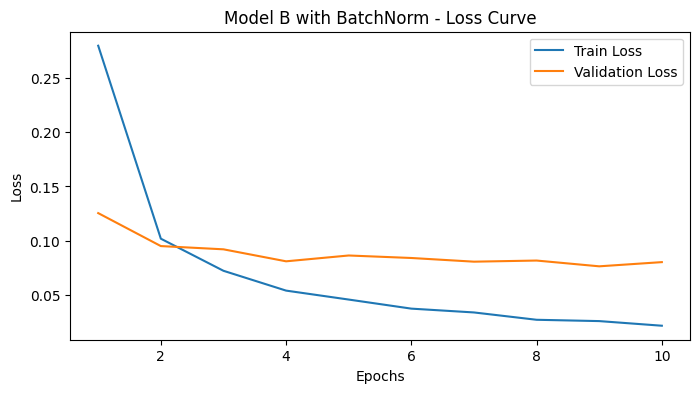

Model B with BatchNorm - Test Accuracy: 97.75%



In [22]:
print("Training Model B with Batch Normalization")
Model_B_BatchNorm, _, _, _ = train_and_evaluate(Model_B_BatchNorm, "Model B with BatchNorm", epochs=10)

In [23]:
print(f"Parameters in Model B (Without BN): {count_parameters(Model_B)}")
print(f"Parameters in Model B (With BN): {count_parameters(Model_B_BatchNorm)}")

Parameters in Model B (Without BN): 109386
Parameters in Model B (With BN): 109770


# Task 5 - Error Analysis
### Model B + BatchNorm.

In [24]:
best_model = Model_B_BatchNorm
best_model.eval()

all_preds = []
all_labels = []
misclassified_imgs = []
misclassified_preds = []
misclassified_trues = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Identify misclassifications
        wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_idx:
            if len(misclassified_imgs) < 10:
                misclassified_imgs.append(images[idx].cpu())
                misclassified_preds.append(predicted[idx].item())
                misclassified_trues.append(labels[idx].item())



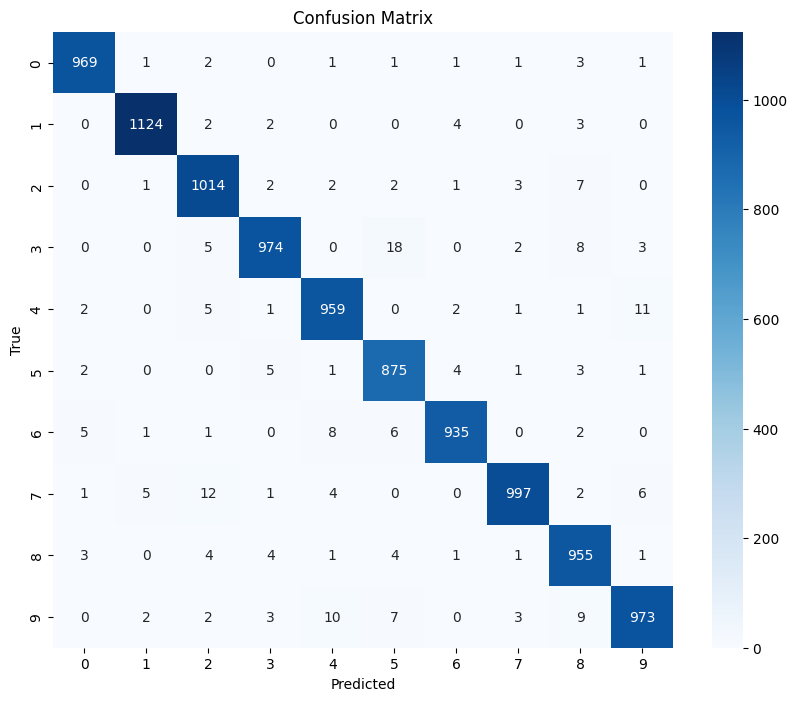

In [25]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

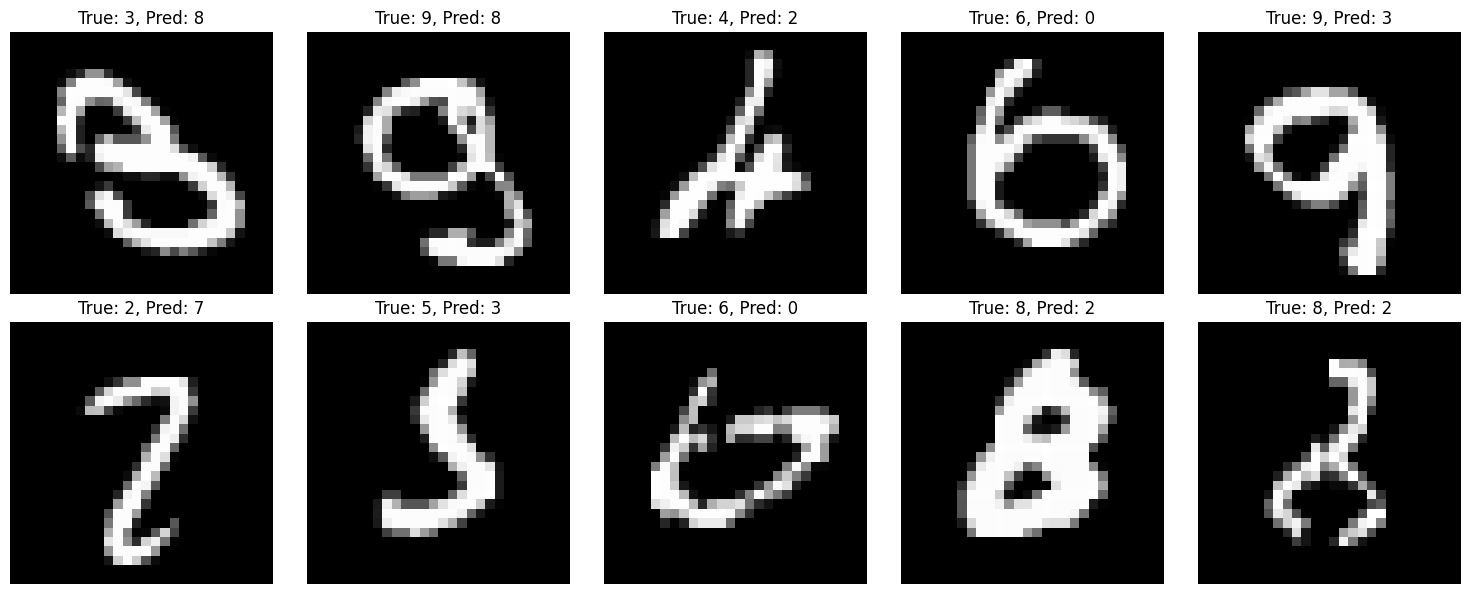

In [26]:
# Misfire
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    if i < len(misclassified_imgs):
        img = misclassified_imgs[i].squeeze() * 0.5 + 0.5
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {misclassified_trues[i]}, Pred: {misclassified_preds[i]}")
        axes[i].axis('off')
plt.tight_layout()
plt.show()

#Task 6 - Model Efficiency Comparison

In [27]:
df_results = pd.DataFrame.from_dict(model_results, orient='index')
df_results.reset_index(inplace=True)
df_results.rename(columns={'index': 'Model', 'params': 'Parameters', 'accuracy': 'Accuracy (%)', 'time': 'Training Time (s)'}, inplace=True)
print("\n--- Model Efficiency Comparison ---")
print(df_results.to_string(index=False))


--- Model Efficiency Comparison ---
                 Model  Parameters  Training Time (s)  Accuracy (%)
               Model A       25450         159.490922         95.45
               Model B      109386         164.881294         96.82
               Model C      242762         183.661266         97.77
        Model Underfit        3190         144.027192         31.53
         Model Overfit     1764426         502.150497         97.36
Model B with BatchNorm      109770         155.660667         97.75


#Gradient Stability Investigation

Training Deep Model (8 layers) WITHOUT BatchNorm
Epoch [1/10] - Train Loss: 0.9476, Val Loss: 0.4034, Val Acc: 89.27%
Epoch [2/10] - Train Loss: 0.3089, Val Loss: 0.2522, Val Acc: 93.55%
Epoch [3/10] - Train Loss: 0.2096, Val Loss: 0.1941, Val Acc: 94.74%
Epoch [4/10] - Train Loss: 0.1651, Val Loss: 0.1658, Val Acc: 95.84%
Epoch [5/10] - Train Loss: 0.1325, Val Loss: 0.1477, Val Acc: 96.03%
Epoch [6/10] - Train Loss: 0.1193, Val Loss: 0.1250, Val Acc: 96.65%
Epoch [7/10] - Train Loss: 0.1039, Val Loss: 0.1700, Val Acc: 95.66%
Epoch [8/10] - Train Loss: 0.0946, Val Loss: 0.1171, Val Acc: 97.00%
Epoch [9/10] - Train Loss: 0.0855, Val Loss: 0.1193, Val Acc: 96.84%
Epoch [10/10] - Train Loss: 0.0771, Val Loss: 0.1365, Val Acc: 96.59%


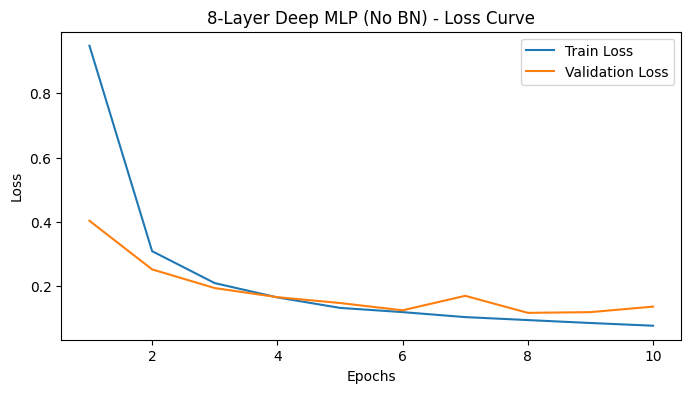

8-Layer Deep MLP (No BN) - Test Accuracy: 96.99%



In [28]:
Deep_Model_No_BN = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 10)
)

print("Training Deep Model (8 layers) WITHOUT BatchNorm")
_, losses_no_bn_train, _, acc_no_bn = train_and_evaluate(Deep_Model_No_BN, "8-Layer Deep MLP (No BN)", epochs=10)

Training Deep Model (8 layers) WITH BatchNorm
Epoch [1/10] - Train Loss: 0.3926, Val Loss: 0.1552, Val Acc: 95.71%
Epoch [2/10] - Train Loss: 0.1603, Val Loss: 0.1215, Val Acc: 96.42%
Epoch [3/10] - Train Loss: 0.1200, Val Loss: 0.0948, Val Acc: 97.49%
Epoch [4/10] - Train Loss: 0.0910, Val Loss: 0.0798, Val Acc: 97.77%
Epoch [5/10] - Train Loss: 0.0805, Val Loss: 0.0875, Val Acc: 97.57%
Epoch [6/10] - Train Loss: 0.0716, Val Loss: 0.0990, Val Acc: 97.14%
Epoch [7/10] - Train Loss: 0.0632, Val Loss: 0.0768, Val Acc: 97.95%
Epoch [8/10] - Train Loss: 0.0529, Val Loss: 0.0743, Val Acc: 97.94%
Epoch [9/10] - Train Loss: 0.0509, Val Loss: 0.0762, Val Acc: 97.96%
Epoch [10/10] - Train Loss: 0.0409, Val Loss: 0.0679, Val Acc: 98.13%


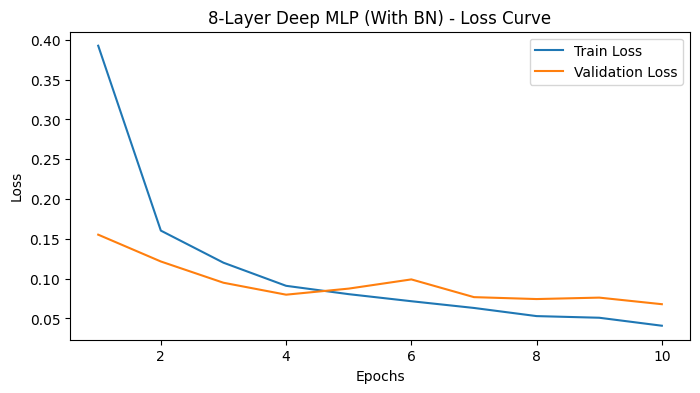

8-Layer Deep MLP (With BN) - Test Accuracy: 98.14%



In [29]:
Deep_Model_With_BN = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
    nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(),
    nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(),
    nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
    nn.Linear(32, 10)
)

print("Training Deep Model (8 layers) WITH BatchNorm")
_, losses_bn_train, _, acc_bn = train_and_evaluate(Deep_Model_With_BN, "8-Layer Deep MLP (With BN)", epochs=10)

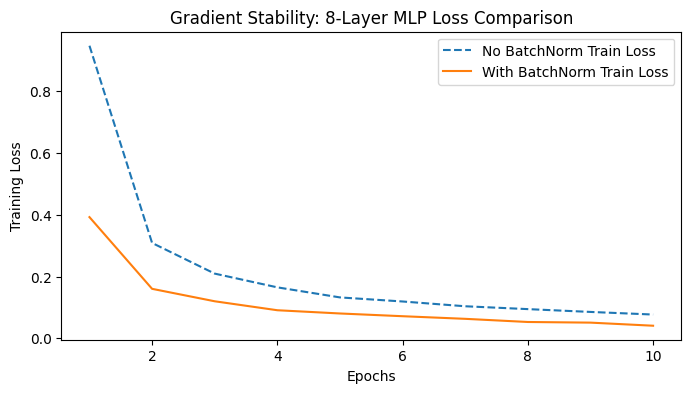

In [30]:
# Compare Loss Curves directly
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), losses_no_bn_train, label='No BatchNorm Train Loss', linestyle='--')
plt.plot(range(1, 11), losses_bn_train, label='With BatchNorm Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Gradient Stability: 8-Layer MLP Loss Comparison')
plt.legend()
plt.show()

In [31]:
print(f"Final Test Accuracy WITHOUT BatchNorm: {acc_no_bn:.2f}%")
print(f"Final Test Accuracy WITH BatchNorm: {acc_bn:.2f}%")

Final Test Accuracy WITHOUT BatchNorm: 96.99%
Final Test Accuracy WITH BatchNorm: 98.14%
